# Correlation Analyses

In [1]:
import mplfinance as mpf
import kagglehub
import pandas as pd
import os
import shutil
import numpy as np

c:\Users\adria\miniconda3\envs\IAI600\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preparing the data
### Downloading the data

In [2]:
filename = "btcusd_1-min_data.csv"
local_csv = os.path.join(os.getcwd(), filename)

if os.path.isfile(local_csv):
    path = os.getcwd()
    print("Using existing dataset:", local_csv)
else:
    path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
    print("Path to dataset files:", path)

Using existing dataset: c:\Users\adria\My Drive\TAMAU\Git\Proyecto IAI\IAI600-final-project\btcusd_1-min_data.csv


### Loading the data
Checks if there's a local version of the csv then loads it into the `df_BTC` variable.

In [3]:
if not os.path.isfile(local_csv):
    source_csv = os.path.join(path, filename)

    if not os.path.isfile(source_csv):
        raise FileNotFoundError(f"Dataset CSV not found: {source_csv}")

    if os.path.abspath(source_csv) != os.path.abspath(local_csv):
        shutil.copy2(source_csv, local_csv)

df_BTC = pd.read_csv(local_csv)
print(f"{filename} structure:")
df_BTC.head()


btcusd_1-min_data.csv structure:


,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


In [4]:
print("df_BTC.info():")
df_BTC.info()

df_BTC.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7766111 entries, 0 to 7766110
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 355.5 MB


In [5]:
print("Checking for null values:")
df_BTC.isnull().sum()

Checking for null values:


Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

## BTC Data Visualized
### Candle Plot
Next we will plot the BTC data in order to get a sense of what we are dealing with.

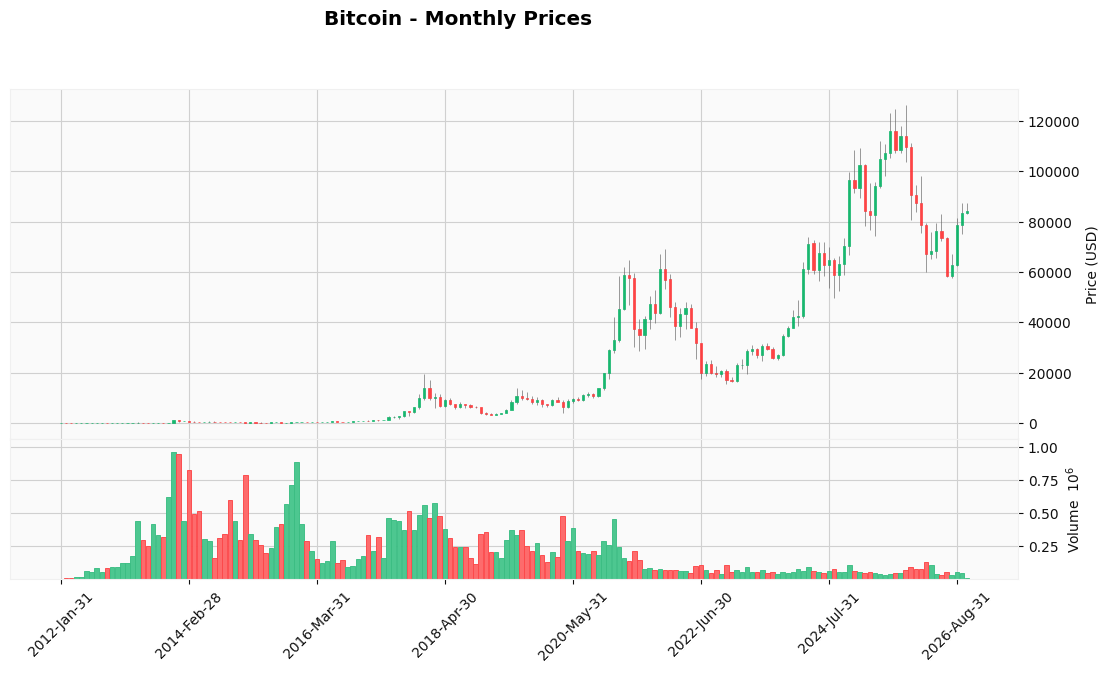

In [6]:

# Convert timestamp Unix to datetime and use it as index for resampling
df_BTC['Timestamp'] = pd.to_datetime(df_BTC['Timestamp'], unit='s')
df_BTC = df_BTC.set_index('Timestamp')

df_BTC_monthly = df_BTC.copy()
# Resampling from 1 minute to monthly
df_BTC_monthly = df_BTC_monthly.resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

# Candle graph of monthly Bitcoin prices
mpf.plot(
    df_BTC_monthly,
    type='candle',
    style='yahoo',
    title='Bitcoin - Monthly Prices',
    ylabel='Price (USD)',
    volume=True,
    figsize=(14, 7)
)

### Bitcoin's Monthly Price Evolution (2012–2026)

*The chart shows Bitcoin's monthly candlesticks from its early days in 2012 to the present, with trading volume displayed below. Several distinct market cycles stand out: a barely visible growth phase until 2016 (when the price moved in a range of a few dollars to a few hundred), followed by the first major speculative bubble in late 2017, which pushed the price to highs near $20,000 before a prolonged decline.*

*Starting in 2020, the asset entered a new bull cycle driven by institutional adoption, reaching new all-time highs in 2021. After a correction in 2022, the price resumed its upward trend from 2023 onward, surpassing $100,000 at the most recent peak visible in the chart, followed by a consolidation/correction phase around $75,000–$80,000.*

*As for volume, the highest peaks (in relative terms) are concentrated in the earlier years, when the market was much smaller and proportionally more volatile, while in the more recent cycles monthly volume — though larger in absolute terms — appears more compressed on the chart's scale due to the overall growth of the market*

## Diferent time frames

For investigating posible correlations between the BTC price and other variables is important to take into consideration the diferent timescales this changes may manifest themselves in. Also the possible lag between a variables movement and BTC price movement has to be considered and will be adressed later in the analisys. 

### Timeframes preparation

In [7]:
ohlcv_aggregation = {
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}

timeframe_rules = {
    '30_minutes': '30min',
    'hourly': 'h',
    '12h': '12h',
    'daily': 'D',
    '3_days': '3D',
    'weekly': 'W',
    '2_weeks': '2W',
    'monthly': 'ME',
    '3_months': '3ME'
}

timeframe_days_per_frame = {
    '30_minutes': '1/48',
    'hourly': '1/24',
    '12h': '1/2',
    'daily': '1',
    '3_days': '3',
    'weekly': '7',
    '2_weeks': '14',
    'monthly': '30',
    '3_months': '90'
}

df_BTC_timeframes = {
    name: df_BTC.resample(rule).agg(ohlcv_aggregation).dropna()
    for name, rule in timeframe_rules.items()
}

# Individual dataframes, if you want to reference them directly
df_BTC_30_minutes = df_BTC_timeframes['30_minutes']
df_BTC_hourly = df_BTC_timeframes['hourly']
df_BTC_12h = df_BTC_timeframes['12h']
df_BTC_daily = df_BTC_timeframes['daily']
df_BTC_3_days = df_BTC_timeframes['3_days']
df_BTC_weekly = df_BTC_timeframes['weekly']
df_BTC_2_weeks = df_BTC_timeframes['2_weeks']
df_BTC_monthly = df_BTC_timeframes['monthly']
df_BTC_3_months = df_BTC_timeframes['3_months']


### Percentual changes
Next we recalculate the variables as percentual change.

In [8]:
for name, frame in df_BTC_timeframes.items():
    change = frame['Close'].pct_change().fillna(0)
    frame['Return'] = change
    frame['Pct_Change'] = change * 100

#### *Example: Last 48 hours*

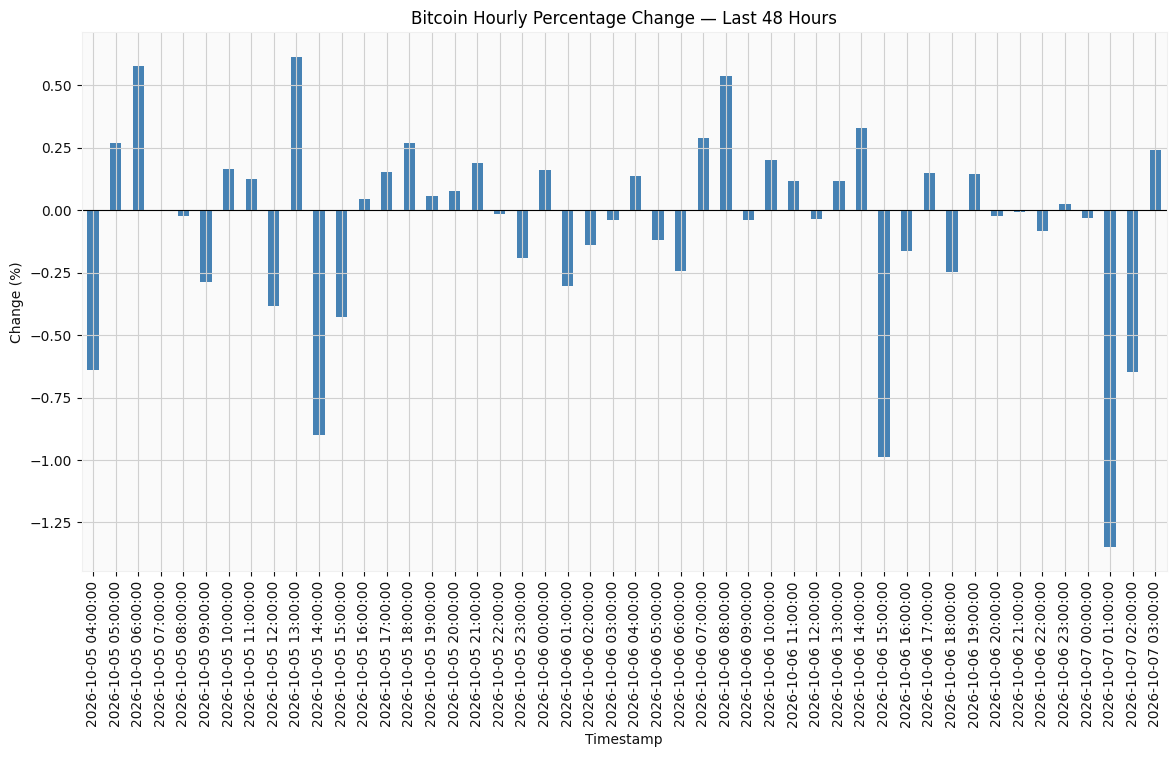

In [9]:
from matplotlib import pyplot as plt


recent_changes = df_BTC_hourly['Pct_Change'].tail(48)

ax = recent_changes.plot(kind='bar', figsize=(14, 7), color='steelblue')
ax.set_title('Bitcoin Hourly Percentage Change — Last 48 Hours')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Change (%)')
ax.tick_params(axis='x', labelrotation=90)
ax.axhline(0, color='black', linewidth=0.8)
plt.show()

## Breif Insight in to the data

In [10]:
from fractions import Fraction

for name, frame in df_BTC_timeframes.items():
    mean_pct = frame["Pct_Change"].mean()
    mean_eqv = mean_pct / float(Fraction(timeframe_days_per_frame[name]))
    print(f"{name:>10} timeframe mean: {mean_pct: 2.3f}%, daily equivalence: {mean_eqv:.3f} %")

30_minutes timeframe mean:  0.006%, daily equivalence: 0.308 %
    hourly timeframe mean:  0.012%, daily equivalence: 0.291 %
       12h timeframe mean:  0.134%, daily equivalence: 0.268 %
     daily timeframe mean:  0.262%, daily equivalence: 0.262 %
    3_days timeframe mean:  0.777%, daily equivalence: 0.259 %
    weekly timeframe mean:  1.838%, daily equivalence: 0.263 %
   2_weeks timeframe mean:  3.845%, daily equivalence: 0.275 %
   monthly timeframe mean:  9.630%, daily equivalence: 0.321 %
  3_months timeframe mean:  32.799%, daily equivalence: 0.364 %


30_minutes timeframe


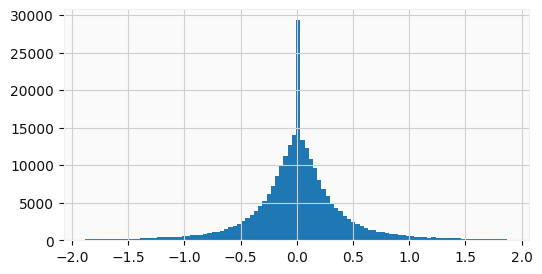

    hourly timeframe


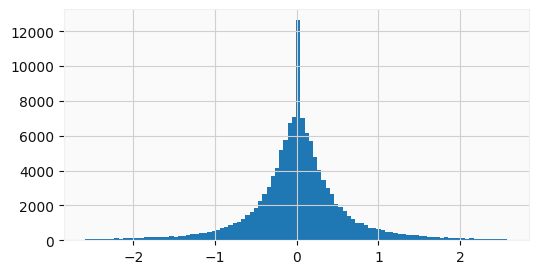

       12h timeframe


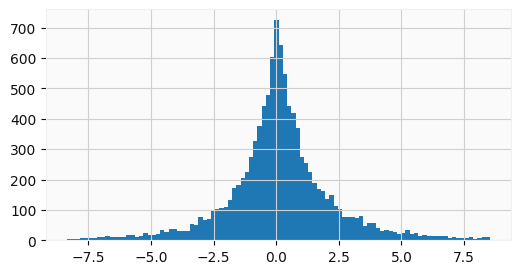

     daily timeframe


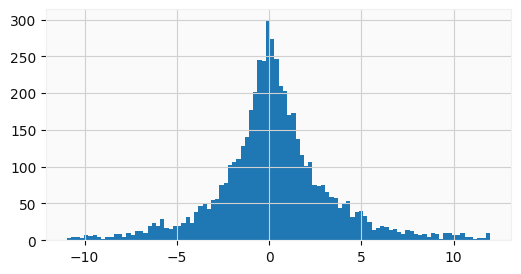

    3_days timeframe


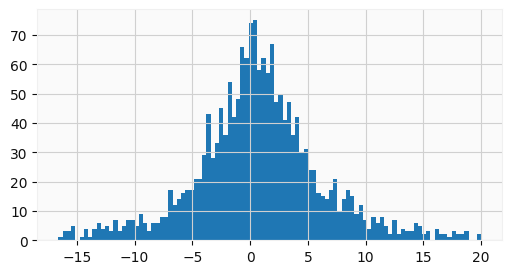

    weekly timeframe


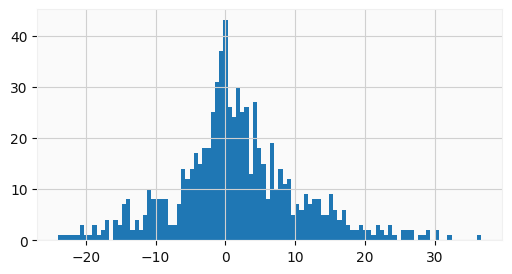

   2_weeks timeframe


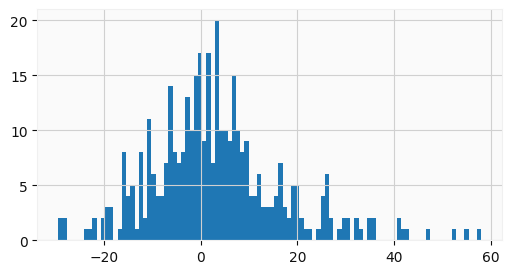

   monthly timeframe


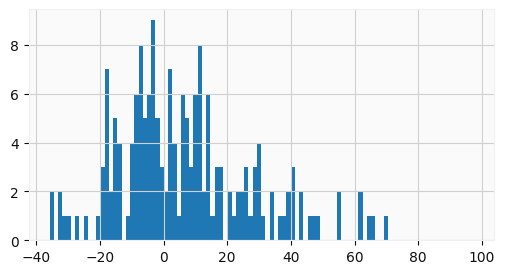

  3_months timeframe


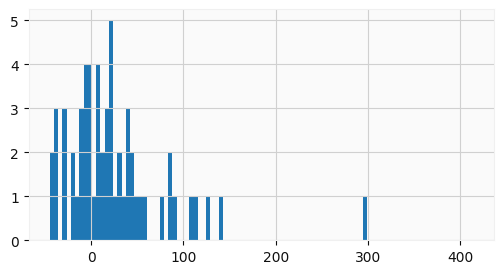

In [11]:
for name, frame in df_BTC_timeframes.items():
    beans = 100
    print(f"{name:>10} timeframe")
    values = frame["Pct_Change"]
    low, high = values.quantile([0.01, 0.99])
    values = values[values.between(low, high)]
    frame['Pct_Change'].hist(bins= int(beans), figsize=(6,3), range=(low, high))
    plt.show()

## Exploring other variables

In [ ]:
import importlib, macro_panel, corr_tools
importlib.reload(macro_panel); importlib.reload(corr_tools)
from macro_panel import build_panel
from corr_tools import *

START = "2017-01-01"   # before 2017 BTC was very small/illiquid; change it and compare
# pit=False: alignment by observation date (contemporaneous correlation)
panel_d, meta = build_panel(df_BTC_daily["Close"],   freq="D",  start=START, weekdays_only=True)
panel_w, _    = build_panel(df_BTC_weekly["Close"],  freq="W",  start=START)
panel_m, _    = build_panel(df_BTC_monthly["Close"], freq="ME", start=START)
print(panel_d.shape, panel_w.shape, panel_m.shape)

### Data coverage
Check that no series has truncated history (e.g. licensed series on FRED) before interpreting anything.

In [ ]:
cov = panel_d.drop(columns=list(TARGETS)).notna().mean().sort_values()
display(cov.to_frame("fraction_with_data").join(meta[["source", "id", "group"]]).head(15))

## Correlations with BTC
Spearman (robust to fat tails). `q_FDR` corrects for multiple comparisons: with ~40 variables, several will show p<0.05 by chance alone.

In [ ]:
for name, p in [("DAILY (weekdays)", panel_d), ("WEEKLY", panel_w), ("MONTHLY", panel_m)]:
    print(f"\n=== {name} ===")
    display(corr_table(p, "BTC_ret").round(3).head(12))

### Correlation with the size of the move (|return|)
Many risk variables (VIX, spreads) relate more to BTC's volatility than to its direction.

In [ ]:
display(corr_table(panel_d, "BTC_absret").round(3).head(12))

## Redundancy among macro variables
Variables that are highly correlated with each other (e.g. SP500/NASDAQ, US10Y/US30Y) do not provide independent information; keep this in mind before using them as features.

In [ ]:
c = panel_d.drop(columns=list(TARGETS)).corr(method="spearman")
order = cluster_order(c)
heatmap(c.loc[order, order], "Spearman between variables (daily), grouped by cluster", vmax=1, annot=False, figsize=(11, 10))
plt.show()

## Lead-lag
Panel with `pit=True` (availability date). k>0: the variable leads BTC by k periods.

In [ ]:
pd_pit, _ = build_panel(df_BTC_daily["Close"],  freq="D", pit=True, start=START)
pw_pit, _ = build_panel(df_BTC_weekly["Close"], freq="W", pit=True, start=START)
heatmap(lead_lag(pd_pit, max_lag=5), "Daily lead-lag (BTC_ret vs X shifted k days)", vmax=0.2, xlabel="k (days)")
heatmap(lead_lag(pw_pit, max_lag=4), "Weekly lead-lag", vmax=0.3, xlabel="k (weeks)")
plt.show()

## Stability over time
An average correlation can hide different regimes.

In [ ]:
key = [v for v in ["SP500", "NASDAQ", "DXY", "US10Y", "Gold", "VIX", "HY_OAS", "NetLiquidity"] if v in panel_d.columns]
rolling_corr_plot(panel_d, key, window=180)
plt.show()
display(corr_by_year(panel_d, key).round(2))

https://arxiv.org/html/2407.13278v1